In [ ]:
#Aufgabe 2_1
#Wir haben die Tabelle aus Aufgabe 1 übernommen.
#Zunächst wandeln wir zur Sicherheit alle 0 Werte in NA um, daraufhin droppen wir diese Zeilen.
import pandas as pd
import numpy as np
listings_2 = pd.read_csv("listings_1_13.csv", index_col="Unnamed: 0")
listings_2["price"] = listings_2["price"].replace(0, pd.NA)
listings_2.dropna(subset=["price"], inplace=True)

print(listings_2.columns)


listings_2_1 = listings_2[["price", "accommodates","amenities_length","latitude","longitude", "bedrooms", "host_is_superhost", "Shared_bath_status", "instant_bookable", "bathrooms_number"]]
#Drops NA
listings_2_1.dropna(inplace=True)
listings_2_1["price"] = listings_2_1["price"].apply(np.log)
listings_2_1.rename(columns={"price":"log_price"}, inplace=True)
#We have checked that there are no NA values.  No further cleaning is necessary.

#print(len(listings_2["price"]))
#Ziel: Price
#Chosen Predictors: "region_median_price","latitude","longitude", "accommodates", "bedrooms", "host_is_superhost", "Shared_bath_status", instant_bookable", "bathrooms_number"
#listings_2_1.head()
#print(listings_2_1.isna().sum())
#Here we calculated the samplesize.
print(len(listings_2_1))

Index(['price', 'neighbourhood_cleansed', 'latitude', 'longitude', 'room_type',
       'bedrooms', 'bathrooms_number', 'accommodates', 'amenities',
       'host_is_superhost', 'host_listings_count', 'host_response_rate',
       'review_scores_rating', 'review_scores_cleanliness',
       'number_of_reviews', 'reviews_per_month', 'minimum_nights',
       'availability_365', 'instant_bookable', 'Shared_bath_status',
       'host_tenure_years', 'amenities_length', 'region_geo',
       'region_median_price', 'above_local_median'],
      dtype='str')
9203


Based upon the results of the previous task, we were able to see some of the chosen correlating parameters. We further added some of the parameters that were not included in the previous task, such as the number of bedrooms and bathrooms, because we believe they have a significant impact on the price of the house.

In [ ]:
#Wir haben die Variablen latitude und longitude in eine Distanzvariable zum Stadtzentrum transformiert. Der Grund dafür ist, dass der Einfluss der Lage auf den Preis plausibel nicht linear entlang einer einzelnen geografischen Achse verläuft. Stattdessen ist zu erwarten, dass sich der Preiseffekt radial vom Stadtzentrum aus verändert, sodass vor allem die Entfernung zum Zentrum – und nicht die absolute Position in Nord-Süd- oder Ost-West-Richtung – für die Preisbildung relevant ist.
#Add distance from dataset geographic center using Euclidean distance.
   
lon_center = listings_2_1["longitude"].mean()
lat_center = listings_2_1["latitude"].mean()

listings_2_1["distance_center"] = np.sqrt(
    (listings_2_1["latitude"] - lat_center) ** 2 +
    (listings_2_1["longitude"] - lon_center) ** 2
)
  
listings_2_1 = listings_2_1.drop(columns=["latitude", "longitude"])

In [118]:
#Aufgabe_2_2
import statsmodels.api as sm
outcome = listings_2_1["log_price"]
regressor = listings_2_1.drop(columns=["log_price"])
regressor = sm.add_constant(regressor)

bool_cols = regressor.select_dtypes("bool").columns
regressor[bool_cols] = regressor[bool_cols].astype(int)
#print(regressor.dtypes)
olssim = sm.OLS(outcome, regressor)
olssim = olssim.fit()
olssim.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_price   R-squared:                       0.406
Model:                            OLS   Adj. R-squared:                  0.405
Method:                 Least Squares   F-statistic:                     698.2
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:12:33   Log-Likelihood:                -6760.0
No. Observations:                9203   AIC:                         1.354e+04
Df Residuals:                    9193   BIC:                         1.361e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                -27.0351      8.137     -3.323      0.001     -42.985     -11.086
accommodates           0.0888      0.004     24.292      0.000       0.082       0.096
amenities_length       0.0003   1.87e-05     14.585      0.000       0.000       0.000
latitude               0.6117      0.151      4.054      0.000       0.316       0.907
longitude             -0.0837      0.073     -1.148      0.251      -0.227       0.059
bedrooms               0.1040      0.009     11.463      0.000       0.086       0.122
host_is_superhost      0.0421      0.012      3.589      0.000       0.019       0.065
Shared_bath_status    -0.4573      0.015    -30.294      0.000      -0.487      -0.428
instant_bookable       0.2285      0.011     20.398      0.000       0.207       0.250
bathrooms_number       0.1029      0.012      8.290      0.000       0.079       0.127
==============================================================================
Omnibus:                     4368.464   Durbin-Watson:                   1.617
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           113464.658
Skew:                           1.720   Prob(JB):                         0.00
Kurtosis:                      19.854   Cond. No.                     9.54e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.54e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

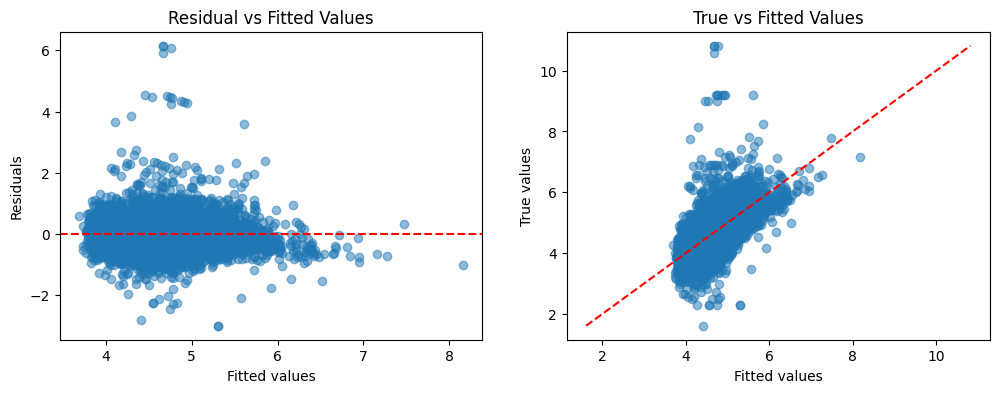

In [119]:
#Aufgabe_2_3

import matplotlib.pyplot as plt

fitted = olssim.fittedvalues
residuals = olssim.resid

fig,ax = plt.subplots(1, 2,figsize=(12, 4))

ax[0].scatter(fitted, residuals, alpha=0.5)
ax[0].axhline(0, color='red', linestyle='--')
ax[0].set_xlabel("Fitted values")
ax[0].set_ylabel("Residuals")
ax[0].set_title("Residual vs Fitted Values")

ax[1].scatter(fitted, outcome, alpha=0.5)
ax[1].plot([outcome.min(), outcome.max()],[outcome.min(), outcome.max()], 'r--')
ax[1].set_xlabel("Fitted values")
ax[1].set_ylabel("True values")
ax[1].set_title("True vs Fitted Values")

plt.show()


The residual-vs-fitted-values plot shows that the residuals are roughly centered around zero without a clear systematic pattern, suggesting that the linear specification of the model is reasonable. However, the spread of residuals appears to decrease slightly as the fitted values increase, which may indicate mild heteroskedasticity. A few outliers are also visible.
The residuals are centered around zero, indicating that the model does not systematically over- or underpredict the outcome.